# ftir_41 — Adama three-method reconciliation: reference definition and total-carbon recovery

## tl;dr

Adama is the only same-corridor place where thermal OC/EC under **both** optical
conventions, FTIR carbon, and HIPS absorption go on one table: five July-2024 date-paired
quartz/PTFE samples (different physical filters; two pairs carry comparability flags).
Three results. **(1) The reference definition is a split question, not a recovery
question**: EC_TOT is 15.4–20.6% lower than EC_TOR (median **−19.0%**), the pyrolysis
term is **0.50–0.63 of EC itself**, and OC+EC is identical across conventions to
≤1e-13 µg/m³ — no choice of thermal split can close a total-carbon gap. **(2) The FTIR
sum is low on all five dates** — OC+EC(FTIR) / OC+EC(thermal) = **0.40–0.74, median
0.51** — and the deficit is **OC-dominated**: OC_ftir/OC_TOR median 0.46, while
EC_ftir/EC_TOT has median **0.86** (unflagged pairs 0.79–1.02). Judged against the
transmittance convention, FTIR EC is close to the thermal reference; the discrepancy is a
carbon-recovery/OC question, and part of it is expected media physics (uncorrected quartz
adsorption artifact inflates the denominator). **(3) Implied MAC exceeds the physical EC
range under every EC definition** — unflagged medians **16.5 (vs EC_TOR), 20.8 (vs
EC_TOT), 23.5 (vs FTIR EC) m²/g** — far above 4–13, yet far below the ≈47 m²/g the
ftir_16 Addis composition bridge implies. Same-corridor absorption exceeds what EC can
explain by ×1.5–2, not ×4.

## Context & Methods

The July 2024 Adama campaign shipped two co-located samplers: a quartz channel analyzed by
thermal-optical carbon (Batch 54, five filters, full fraction set) and a PTFE channel
analyzed by both FTIR and HIPS (CSU AMOD Batch 54, five filters). Older phase-3 notes
treated Adama as "quartz only, no FTIR/HIPS on the same filters" — true per physical
filter, but the PTFE twins exist and pair by sampling date. That makes Adama the only
same-corridor sample where FTIR carbon, HIPS absorption, and thermal OC/EC under **both**
optical conventions (reflectance TOR and transmittance TOT) can be put on one table.

Three questions, in order:

1. **What does the thermal reference definition change?** TOR vs TOT redistributes carbon
   between OC and EC via the pyrolysis split point; total carbon should be conserved
   within one thermal analysis.
2. **Does FTIR miss the split or the total?** Compare FTIR OC, EC, and OC+EC against the
   quartz thermal values — per component, not just EC.
3. **What MAC do the direct EC references imply?** Fabs / EC under each convention,
   against the physical EC MAC range and the deployed MAC = 10 / MAC = 6 fork.

### Key assumptions

- Date-paired quartz/PTFE samples are **co-located but different physical filters and
  different media**. Every comparison here is a paired-sampler comparison, not a
  same-filter replicate.
- Two pairs have documented comparability issues surfaced by the ledger below (a ~40-min
  start offset on July 9; a ~60% low PTFE volume on July 30). They are flagged in every
  figure, **not excluded and not corrected** — sampler-log review is the follow-up, and
  this notebook must not tune agreement.
- Quartz OC carries a positive gas-adsorption artifact (no backup-filter correction is
  present in the export); FTIR OC on PTFE does not. Part of any OC gap is expected from
  media/artifact physics, not calibration failure.
- EC_TOT is checked against its construction EC_TOT = EC_TOR + OPTR − OPTT.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, './scripts')
sys.path.insert(0, '../ftir_hips_chem/scripts')

from plotting import apply_default_style
from theory_test_suite import davis_root

apply_default_style()
OUT = Path('output/tables/ftir41')
PLOTS = Path('output/plots/ftir41')
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

ADAMA = davis_root() / 'DAVIS/Adama TOR'
AMOD = davis_root() / 'DAVIS/CSU_AMOD'
MAC_HEADLINE, MAC_ALT = 10.0, 6.0
EC_MAC_PHYSICAL = (4.0, 13.0)   # literature range for pure EC at 633 nm, per ftir_16

## Data

### The five date pairs and their comparability ledger

Grain: one row per sampling date. `start_offset_min` is quartz start minus PTFE start;
`volume_ratio` is PTFE volume over quartz volume (both nominally 2 L/min × 24 h).

In [2]:
carbon = pd.read_csv(ADAMA / 'Carbon_concs_Batch54.csv')
carbon['date'] = pd.to_datetime(carbon['SampleDate']).dt.normalize()
quartz = carbon.pivot_table(
    index=['FilterId', 'date', 'SampleDate', 'Volume_liters', 'ElapsedTime_hrs'],
    columns='Parameter', values='Concentration_ug_m3').reset_index()
quartz.columns.name = None

ftir = pd.read_csv(AMOD / 'csu_amod_FTIR_Batch_54.csv', encoding='cp1252')
ptfe = ftir.pivot_table(index=['FilterId', 'SampleDate', 'Volume_m3'],
                        columns='Parameter', values='Concentration_ug_m3').reset_index()
ptfe.columns.name = None
ptfe['date'] = pd.to_datetime(ptfe['SampleDate']).dt.normalize()

hips = pd.read_csv(AMOD / 'csu_amod_HIPS_Batch_54.csv', encoding='cp1252')
hips['date'] = pd.to_datetime(hips['SampleDate']).dt.normalize()

pairs = (ptfe.merge(hips[['date', 'FilterId', 'Fabs', 'tau', 'T1', 'R1', 'Uncertainty']],
                    on='date', suffixes=('', '_hips'))
             .merge(quartz, on='date', suffixes=('_ptfe', '_quartz'))
             .sort_values('date').reset_index(drop=True))
assert pairs['FilterId_ptfe'].equals(pairs['FilterId_hips']), 'FTIR and HIPS PTFE ids differ'

pairs['start_offset_min'] = (
    pd.to_datetime(pairs['SampleDate_quartz']) - pd.to_datetime(pairs['SampleDate_ptfe'])
).dt.total_seconds() / 60
pairs['volume_ratio'] = pairs['Volume_m3'] / (pairs['Volume_liters'] / 1000)
pairs['flag'] = ''
pairs.loc[pairs['start_offset_min'].abs() > 5, 'flag'] += 'start-offset '
# The two channels routinely differ by ~10% in logged volume; only a gross
# mismatch (>20%) is a comparability flag. July 30's PTFE volume is 46% of quartz.
pairs.loc[(pairs['volume_ratio'] - 1).abs() > 0.2, 'flag'] += 'volume-mismatch'
pairs['flag'] = pairs['flag'].str.strip()

ledger = pairs[['date', 'FilterId_ptfe', 'FilterId_quartz', 'Volume_m3', 'Volume_liters',
                'start_offset_min', 'volume_ratio', 'flag']].copy()
ledger.to_csv(OUT / 'pairing_ledger.csv', index=False)
display(ledger.round(3))

,date,FilterId_ptfe,FilterId_quartz,Volume_m3,Volume_liters,start_offset_min,volume_ratio,flag
0,2024-07-09,J1269,J1693,2.879,2620.69,39.733,1.098,start-offset
1,2024-07-20,J1266,J1701,2.880,2606.26,-0.083,1.105,
2,2024-07-23,J1285,J1675,2.882,2585.44,-0.250,1.115,
3,2024-07-26,J1233,J1703,2.881,2582.91,0.150,1.116,
4,2024-07-30,J1270,J1679,1.161,2547.07,-0.250,0.456,volume-mismatch


## Results

### 1. The reference definition redistributes carbon; it does not change total carbon

EC_TOT is confirmed against EC_TOR + OPTR − OPTT, and OC+EC is compared across the two
conventions within the same thermal analysis.

In [3]:
q = pairs
construction_err = (q['ECTT'] - (q['ECTR'] + q['OPTR'] - q['OPTT'])).abs().max()
tc_conservation = ((q['OCTR'] + q['ECTR']) - (q['OCTT'] + q['ECTT'])).abs().max()
ec_shift_pct = (q['ECTT'] / q['ECTR'] - 1) * 100

ref_table = q[['date', 'FilterId_quartz', 'ECTR', 'ECTT', 'OCTR', 'OCTT',
               'OPTR', 'OPTT', 'TCTC']].copy()
ref_table['EC_TT_vs_TR_pct'] = ec_shift_pct
ref_table.to_csv(OUT / 'reference_definition_table.csv', index=False)
display(ref_table.round(3))
print(f'EC_TOT construction check |err| <= {construction_err:.2e} ug/m3')
print(f'OC+EC conservation across conventions |err| <= {tc_conservation:.2e} ug/m3')
print(f'EC_TOT vs EC_TOR: {ec_shift_pct.min():.1f}% to {ec_shift_pct.max():.1f}%, '
      f'median {ec_shift_pct.median():.1f}%')

,date,FilterId_quartz,ECTR,ECTT,OCTR,OCTT,OPTR,OPTT,TCTC,EC_TT_vs_TR_pct
0,2024-07-09,J1693,3.379,2.737,20.784,21.425,1.989,2.631,24.162,-18.996
1,2024-07-20,J1701,2.398,1.947,14.211,14.662,1.239,1.690,16.609,-18.798
2,2024-07-23,J1675,2.450,1.944,14.889,15.394,1.544,2.050,17.338,-20.629
3,2024-07-26,J1703,1.862,1.497,13.461,13.825,1.124,1.489,15.323,-19.576
4,2024-07-30,J1679,3.041,2.573,14.077,14.545,1.521,1.990,17.118,-15.396


EC_TOT construction check |err| <= 1.35e-04 ug/m3
OC+EC conservation across conventions |err| <= 9.24e-14 ug/m3
EC_TOT vs EC_TOR: -20.6% to -15.4%, median -19.0%


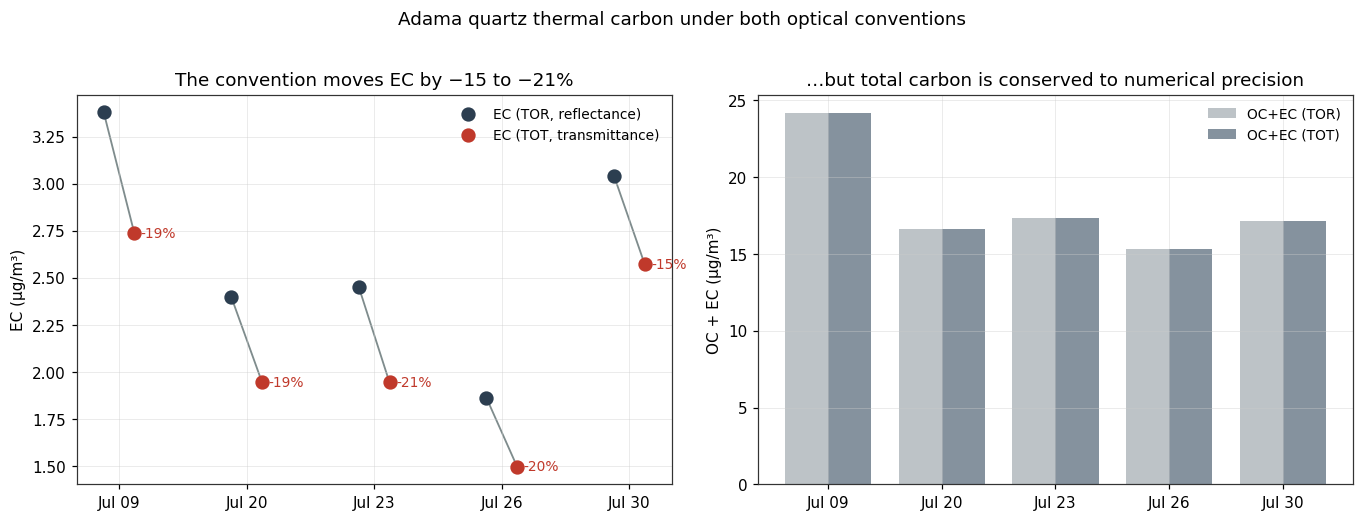

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
dates = q['date'].dt.strftime('%b %d')
x = np.arange(len(q))

ax = axes[0]
for i in x:
    ax.plot([i - 0.12, i + 0.12], [q['ECTR'].iloc[i], q['ECTT'].iloc[i]],
            color='#7F8C8D', lw=1.2, zorder=1)
ax.scatter(x - 0.12, q['ECTR'], s=70, color='#2C3E50', label='EC (TOR, reflectance)', zorder=2)
ax.scatter(x + 0.12, q['ECTT'], s=70, color='#C0392B', label='EC (TOT, transmittance)', zorder=2)
for i in x:
    ax.annotate(f'{ec_shift_pct.iloc[i]:+.0f}%', (i + 0.17, q["ECTT"].iloc[i]),
                fontsize=9, color='#C0392B', va='center')
ax.set(xticks=x, xticklabels=dates, ylabel='EC (µg/m³)',
       title='The convention moves EC by −15 to −21%')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
width = 0.38
ax.bar(x - width / 2, q['OCTR'] + q['ECTR'], width, color='#BDC3C7', label='OC+EC (TOR)')
ax.bar(x + width / 2, q['OCTT'] + q['ECTT'], width, color='#85929E', label='OC+EC (TOT)')
ax.set(xticks=x, xticklabels=dates, ylabel='OC + EC (µg/m³)',
       title='…but total carbon is conserved to numerical precision')
ax.legend(frameon=False, fontsize=9)
fig.suptitle('Adama quartz thermal carbon under both optical conventions', y=1.02)
fig.tight_layout()
fig.savefig(PLOTS / 'reference_definition.png', bbox_inches='tight')
plt.show()

### Thermal-fraction structure and the pyrolysis term

The redistribution above is the pyrolysis correction: OPTT − OPTR is exactly the EC
difference. The stacked profile shows where each filter's carbon evolves and how large
the optically-split pyrolysis term is relative to the EC it corrects.

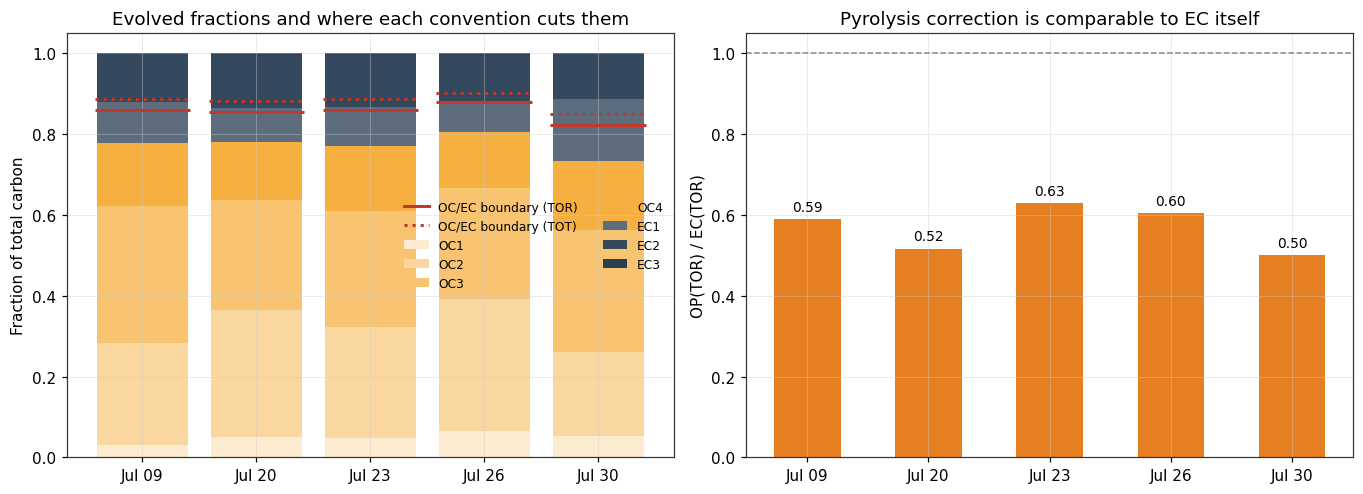

OP/EC(TOR): [0.59, 0.52, 0.63, 0.6, 0.5] | median 0.59


In [5]:
# Evolved fractions: OC1-4 + EC1-3 sum exactly to TC. OP is a *reallocation*
# inside EC1-3 (OC_TOR = OC1-4 + OP; EC_TOR = EC1-3 - OP), so it is drawn as the
# split boundary each convention chooses, not as a ninth fraction.
frac_cols = ['OC1', 'OC2', 'OC3', 'OC4', 'EC1', 'EC2', 'EC3']
frac_colors = ['#FDEBD0', '#FAD7A0', '#F8C471', '#F5B041',
               '#5D6D7E', '#34495E', '#2C3E50']
shares = q[frac_cols].div(q['TCTC'], axis=0)
assert np.allclose(shares.sum(axis=1), 1.0, atol=1e-3)
shares.index = dates

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
bottom = np.zeros(len(q))
for col, color in zip(frac_cols, frac_colors):
    axes[0].bar(dates, shares[col], bottom=bottom, color=color, label=col)
    bottom += shares[col].to_numpy()
oc_share_tor = (q['OCTR'] / q['TCTC']).to_numpy()
oc_share_tot = (q['OCTT'] / q['TCTC']).to_numpy()
for i in range(len(q)):
    axes[0].hlines(oc_share_tor[i], i - 0.42, i + 0.42, color='#C0392B', lw=2)
    axes[0].hlines(oc_share_tot[i], i - 0.42, i + 0.42, color='#C0392B', lw=2, ls=':')
axes[0].plot([], [], color='#C0392B', lw=2, label='OC/EC boundary (TOR)')
axes[0].plot([], [], color='#C0392B', lw=2, ls=':', label='OC/EC boundary (TOT)')
axes[0].set(ylabel='Fraction of total carbon',
            title='Evolved fractions and where each convention cuts them')
axes[0].legend(frameon=False, fontsize=8, ncols=2)

op_over_ec = q['OPTR'] / q['ECTR']
axes[1].bar(dates, op_over_ec, color='#E67E22', width=0.55)
axes[1].axhline(1.0, color='#7F8C8D', ls='--', lw=1)
axes[1].set(ylabel='OP(TOR) / EC(TOR)',
            title='Pyrolysis correction is comparable to EC itself')
for i, v in enumerate(op_over_ec):
    axes[1].annotate(f'{v:.2f}', (i, v + 0.02), ha='center', fontsize=9)
fig.tight_layout()
fig.savefig(PLOTS / 'thermal_fractions.png', bbox_inches='tight')
plt.show()

pyro = pd.DataFrame({'date': q['date'], 'OP_TOR_ugm3': q['OPTR'],
                     'OP_over_EC_TOR': op_over_ec,
                     'OP_share_of_TC': q['OPTR'] / q['TCTC']})
pyro.to_csv(OUT / 'pyrolysis_summary.csv', index=False)
print('OP/EC(TOR):', op_over_ec.round(2).tolist(), '| median', f'{op_over_ec.median():.2f}')

### 2. Total-carbon recovery: the FTIR sum is low on all five dates — and the gap is OC

The decisive decomposition: compare each FTIR component to its thermal counterpart, so a
split problem (errors opposing) can be told apart from a recovery problem (both low).
Flagged pairs are hatched; their ratios are shown but must not be interpreted until the
sampler logs are reviewed.

In [6]:
q['ftir_sum'] = q['OC_ftir'] + q['EC_ftir']
q['tc_thermal'] = q['OCTR'] + q['ECTR']
q['tc_ratio'] = q['ftir_sum'] / q['tc_thermal']
q['oc_ratio_tor'] = q['OC_ftir'] / q['OCTR']
q['ec_ratio_tor'] = q['EC_ftir'] / q['ECTR']
q['ec_ratio_tot'] = q['EC_ftir'] / q['ECTT']

budget = q[['date', 'FilterId_ptfe', 'FilterId_quartz', 'OC_ftir', 'EC_ftir', 'ftir_sum',
            'OCTR', 'ECTR', 'ECTT', 'tc_thermal', 'tc_ratio', 'oc_ratio_tor',
            'ec_ratio_tor', 'ec_ratio_tot', 'flag']].copy()
budget.to_csv(OUT / 'carbon_budget_table.csv', index=False)
display(budget.round(3))
clean = q[q['flag'].eq('')]
print(f"TC ratio (all 5): {q['tc_ratio'].min():.2f}-{q['tc_ratio'].max():.2f}, "
      f"median {q['tc_ratio'].median():.2f}")
print(f"TC ratio (3 unflagged): {clean['tc_ratio'].round(2).tolist()}")
print(f"OC_ftir/OC_TOR median {q['oc_ratio_tor'].median():.2f} | "
      f"EC_ftir/EC_TOR median {q['ec_ratio_tor'].median():.2f} | "
      f"EC_ftir/EC_TOT median {q['ec_ratio_tot'].median():.2f}")

,date,FilterId_ptfe,FilterId_quartz,OC_ftir,EC_ftir,ftir_sum,OCTR,ECTR,ECTT,tc_thermal,tc_ratio,oc_ratio_tor,ec_ratio_tor,ec_ratio_tot,flag
0,2024-07-09,J1269,J1693,12.527,5.277,17.804,20.784,3.379,2.737,24.162,0.737,0.603,1.562,1.928,start-offset
1,2024-07-20,J1266,J1701,5.840,1.532,7.372,14.211,2.398,1.947,16.609,0.444,0.411,0.639,0.787,
2,2024-07-23,J1285,J1675,6.843,1.992,8.835,14.889,2.450,1.944,17.338,0.510,0.460,0.813,1.024,
3,2024-07-26,J1233,J1703,4.909,1.293,6.202,13.461,1.862,1.497,15.323,0.405,0.365,0.694,0.863,
4,2024-07-30,J1270,J1679,8.575,1.767,10.342,14.077,3.041,2.573,17.118,0.604,0.609,0.581,0.687,volume-mismatch


TC ratio (all 5): 0.40-0.74, median 0.51
TC ratio (3 unflagged): [0.44, 0.51, 0.4]
OC_ftir/OC_TOR median 0.46 | EC_ftir/EC_TOR median 0.69 | EC_ftir/EC_TOT median 0.86


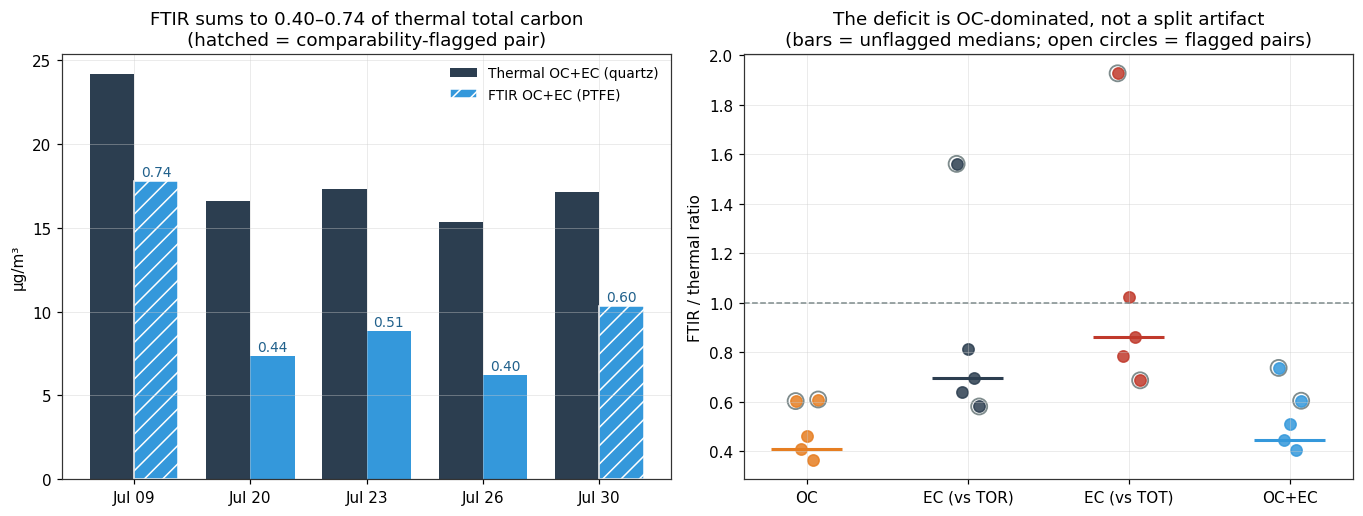

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
width = 0.38
flagged = q['flag'].ne('')

ax = axes[0]
ax.bar(x - width / 2, q['tc_thermal'], width, color='#2C3E50', label='Thermal OC+EC (quartz)')
bars = ax.bar(x + width / 2, q['ftir_sum'], width, color='#3498DB',
              label='FTIR OC+EC (PTFE)')
for i, bar in enumerate(bars):
    if flagged.iloc[i]:
        bar.set_hatch('//')
        bar.set_edgecolor('white')
    ax.annotate(f"{q['tc_ratio'].iloc[i]:.2f}", (bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3), ha='center', fontsize=9, color='#21618C')
ax.set(xticks=x, xticklabels=dates, ylabel='µg/m³',
       title='FTIR sums to 0.40–0.74 of thermal total carbon\n(hatched = comparability-flagged pair)')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ratio_sets = [('OC', q['oc_ratio_tor'], '#E67E22'),
              ('EC (vs TOR)', q['ec_ratio_tor'], '#2C3E50'),
              ('EC (vs TOT)', q['ec_ratio_tot'], '#C0392B'),
              ('OC+EC', q['tc_ratio'], '#3498DB')]
for j, (label, series, color) in enumerate(ratio_sets):
    jitter = (np.arange(len(series)) - 2) * 0.035
    ax.scatter(np.full(len(series), j) + jitter, series, s=55, color=color, alpha=0.85)
    unflagged_median = series[~flagged].median()
    ax.hlines(unflagged_median, j - 0.22, j + 0.22, color=color, lw=2)
for i in np.where(flagged)[0]:
    for j, (_, series, _) in enumerate(ratio_sets):
        ax.scatter(j + (i - 2) * 0.035, series.iloc[i], s=110, facecolors='none',
                   edgecolors='#7F8C8D', lw=1.2)
ax.axhline(1.0, color='#7F8C8D', ls='--', lw=1)
ax.set(xticks=range(4), xticklabels=[r[0] for r in ratio_sets],
       ylabel='FTIR / thermal ratio',
       title='The deficit is OC-dominated, not a split artifact\n(bars = unflagged medians; open circles = flagged pairs)')
fig.tight_layout()
fig.savefig(PLOTS / 'total_carbon_budget.png', bbox_inches='tight')
plt.show()

### 3. Three EC definitions and one absorption measurement

All carbon methods on one axis per date, with the HIPS EC-equivalent band spanning the
MAC = 6 to MAC = 10 fork. Then the direct implied MAC = Fabs / EC for every EC
definition — the number the whole MAC dispute is about, now computable same-corridor
with real EC references for the first time.

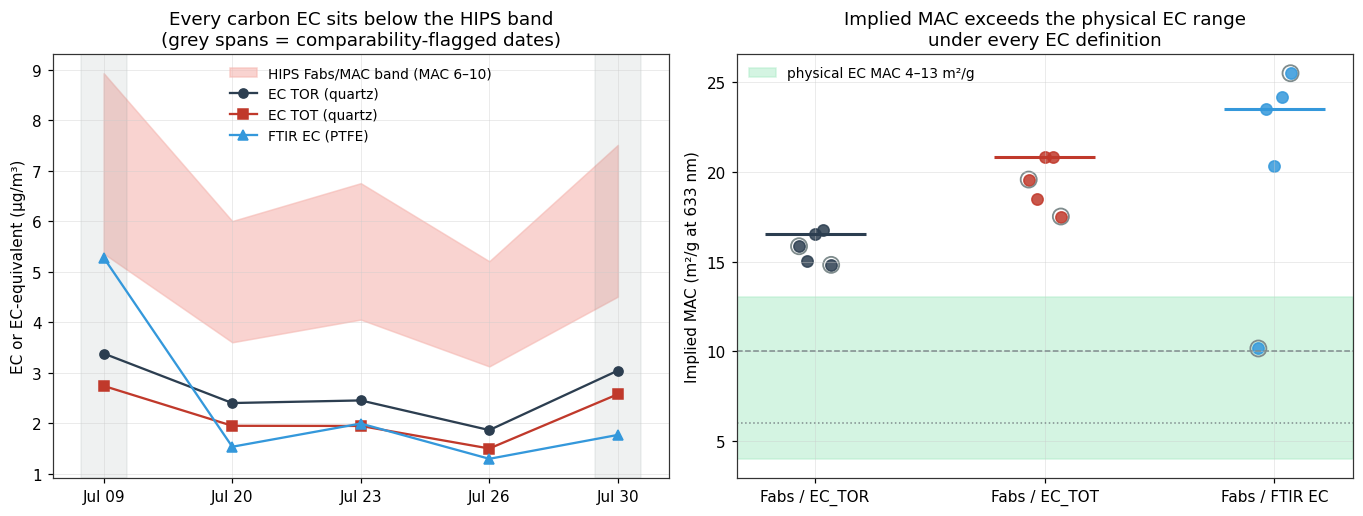

,date,flag,implied_MAC_vs_ECTOR,implied_MAC_vs_ECTOT,implied_MAC_vs_FTIR_EC
0,2024-07-09,start-offset,15.9,19.6,10.2
1,2024-07-20,,15.0,18.5,23.5
2,2024-07-23,,16.5,20.8,20.3
3,2024-07-26,,16.8,20.9,24.2
4,2024-07-30,volume-mismatch,14.8,17.5,25.5


implied_MAC_vs_ECTOR: unflagged median 16.5 m²/g (all-5 median 15.9)
implied_MAC_vs_ECTOT: unflagged median 20.8 m²/g (all-5 median 19.6)
implied_MAC_vs_FTIR_EC: unflagged median 23.5 m²/g (all-5 median 23.5)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

ax = axes[0]
ax.fill_between(x, q['Fabs'] / MAC_HEADLINE, q['Fabs'] / MAC_ALT, color='#F5B7B1',
                alpha=0.6, label=f'HIPS Fabs/MAC band (MAC {MAC_ALT:.0f}–{MAC_HEADLINE:.0f})')
ax.plot(x, q['ECTR'], 'o-', color='#2C3E50', label='EC TOR (quartz)')
ax.plot(x, q['ECTT'], 's-', color='#C0392B', label='EC TOT (quartz)')
ax.plot(x, q['EC_ftir'], '^-', color='#3498DB', label='FTIR EC (PTFE)')
for i in np.where(flagged)[0]:
    ax.axvspan(i - 0.18, i + 0.18, color='#7F8C8D', alpha=0.12)
ax.set(xticks=x, xticklabels=dates, ylabel='EC or EC-equivalent (µg/m³)',
       title='Every carbon EC sits below the HIPS band\n(grey spans = comparability-flagged dates)')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
mac_defs = [('Fabs / EC_TOR', q['Fabs'] / q['ECTR'], '#2C3E50'),
            ('Fabs / EC_TOT', q['Fabs'] / q['ECTT'], '#C0392B'),
            ('Fabs / FTIR EC', q['Fabs'] / q['EC_ftir'], '#3498DB')]
ax.axhspan(*EC_MAC_PHYSICAL, color='#ABEBC6', alpha=0.5,
           label=f'physical EC MAC {EC_MAC_PHYSICAL[0]:.0f}–{EC_MAC_PHYSICAL[1]:.0f} m²/g')
ax.axhline(MAC_HEADLINE, color='#7F8C8D', ls='--', lw=1)
ax.axhline(MAC_ALT, color='#7F8C8D', ls=':', lw=1)
for j, (label, series, color) in enumerate(mac_defs):
    jitter = (np.arange(len(series)) - 2) * 0.035
    ax.scatter(np.full(len(series), j) + jitter, series, s=55, color=color, alpha=0.85)
    ax.hlines(series[~flagged].median(), j - 0.22, j + 0.22, color=color, lw=2)
for i in np.where(flagged)[0]:
    for j, (_, series, _) in enumerate(mac_defs):
        ax.scatter(j + (i - 2) * 0.035, series.iloc[i], s=110, facecolors='none',
                   edgecolors='#7F8C8D', lw=1.2)
ax.set(xticks=range(3), xticklabels=[m[0] for m in mac_defs],
       ylabel='Implied MAC (m²/g at 633 nm)',
       title='Implied MAC exceeds the physical EC range\nunder every EC definition')
ax.legend(frameon=False, fontsize=9, loc='upper left')
fig.tight_layout()
fig.savefig(PLOTS / 'three_method_ec_and_mac.png', bbox_inches='tight')
plt.show()

mac_table = pd.DataFrame({
    'date': q['date'], 'flag': q['flag'],
    'implied_MAC_vs_ECTOR': q['Fabs'] / q['ECTR'],
    'implied_MAC_vs_ECTOT': q['Fabs'] / q['ECTT'],
    'implied_MAC_vs_FTIR_EC': q['Fabs'] / q['EC_ftir'],
})
mac_table.to_csv(OUT / 'implied_mac_table.csv', index=False)
display(mac_table.round(1))
for col in mac_table.columns[2:]:
    unflagged = mac_table.loc[q['flag'].eq(''), col]
    print(f'{col}: unflagged median {unflagged.median():.1f} m²/g '
          f'(all-5 median {mac_table[col].median():.1f})')

## Takeaways

- **Reallocating thermal carbon between OC and EC cannot remove a total-carbon
  discrepancy.** OC+EC is conserved across TOR/TOT to numerical precision, so the
  FTIR-vs-thermal question splits cleanly into a split question (~19% on EC) and a
  recovery question (~2× on total carbon) — and the recovery question is the larger one.
- **FTIR EC is not the problem child here.** Against EC_TOT the unflagged ratios are
  0.79–1.02; against EC_TOR, 0.58–0.81. Any statement that "FTIR EC is biased low vs
  thermal" must name the convention, because the convention moves the answer by ~19%.
- **The OC gap is confounded by media physics.** Quartz OC carries an uncorrected positive
  gas-adsorption artifact and the PTFE/quartz pair are different filters; bounding that
  artifact (backup filters or denuder data, if the lab has them) comes before interpreting
  OC_ftir/OC_TOR ≈ 0.4–0.6 as FTIR under-recovery.
- **Two pairs need sampler-log review, not correction**: July 9 (quartz starts 39.7 min
  after PTFE; also the one anomalous EC pair, FTIR EC 1.9× EC_TOT) and July 30 (PTFE
  volume 0.46× quartz). Both are flagged in every figure and table.
- **Same-corridor implied MAC lands at 15–21 m²/g against real EC references** — above
  the physical EC range (non-EC absorption or filter-photometry enhancement is real here
  too), but nowhere near Addis's bridge value of ≈47. This weakens "the Addis offset is
  just what this aerosol does to HIPS" and keeps the Addis-specific component in play.
- **n = 5 dates, one season, one site.** These are diagnostics and design inputs for the
  ftir_40 quartz campaign, not calibration constants.